In [1]:
from pathlib import Path
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure we can import src.*
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_engineering import evaluate_model

# Load test data
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

models_dir = PROJECT_ROOT / "models"
figures_dir = PROJECT_ROOT / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# Untuned
with open(models_dir / "logistic_regression.pkl", "rb") as f:
    lr = pickle.load(f)
with open(models_dir / "decision_tree.pkl", "rb") as f:
    dt = pickle.load(f)
with open(models_dir / "random_forest.pkl", "rb") as f:
    rf = pickle.load(f)
with open(models_dir / "xgboost.pkl", "rb") as f:
    xgb_clf = pickle.load(f)

# Tuned
with open(models_dir / "logistic_regression_tuned.pkl", "rb") as f:
    lr_t = pickle.load(f)
with open(models_dir / "decision_tree_tuned.pkl", "rb") as f:
    dt_t = pickle.load(f)
with open(models_dir / "random_forest_tuned.pkl", "rb") as f:
    rf_t = pickle.load(f)
with open(models_dir / "xgboost_tuned.pkl", "rb") as f:
    xgb_t = pickle.load(f)

In [3]:
# Untuned metrics
y_pred_lr = lr.predict(X_test);        y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_pred_dt = dt.predict(X_test);        y_proba_dt = dt.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test);        y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_clf.predict(X_test);  y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

results_untuned = {
    "Logistic Regression": evaluate_model(y_test, y_pred_lr, y_proba_lr),
    "Decision Tree":       evaluate_model(y_test, y_pred_dt, y_proba_dt),
    "Random Forest":       evaluate_model(y_test, y_pred_rf, y_proba_rf),
    "XGBoost":             evaluate_model(y_test, y_pred_xgb, y_proba_xgb),
}
comparison_df = pd.DataFrame(results_untuned).T

# Tuned metrics
y_pred_lr_t = lr_t.predict(X_test);        y_proba_lr_t = lr_t.predict_proba(X_test)[:, 1]
y_pred_dt_t = dt_t.predict(X_test);        y_proba_dt_t = dt_t.predict_proba(X_test)[:, 1]
y_pred_rf_t = rf_t.predict(X_test);        y_proba_rf_t = rf_t.predict_proba(X_test)[:, 1]
y_pred_xgb_t = xgb_t.predict(X_test);      y_proba_xgb_t = xgb_t.predict_proba(X_test)[:, 1]

results_tuned = {
    "Logistic Regression": evaluate_model(y_test, y_pred_lr_t, y_proba_lr_t),
    "Decision Tree":       evaluate_model(y_test, y_pred_dt_t, y_proba_dt_t),
    "Random Forest":       evaluate_model(y_test, y_pred_rf_t, y_proba_rf_t),
    "XGBoost":             evaluate_model(y_test, y_pred_xgb_t, y_proba_xgb_t),
}
comparison_tuned_df = pd.DataFrame(results_tuned).T

# Align rows (models)
comparison_df = comparison_df.sort_index()
comparison_tuned_df = comparison_tuned_df.sort_index()
models = comparison_df.index.tolist()

comparison_df, comparison_tuned_df

(                     Accuracy  Precision    Recall  F1-Score   AUC-ROC
 Decision Tree          0.8640   0.798009  0.811867  0.804878  0.851694
 Logistic Regression    0.8545   0.797619  0.775687  0.786500  0.924163
 Random Forest          0.8915   0.851632  0.830680  0.841026  0.954785
 XGBoost                0.8940   0.840683  0.855282  0.847920  0.968474,
                      Accuracy  Precision    Recall  F1-Score   AUC-ROC
 Decision Tree          0.8780   0.829161  0.814761  0.821898  0.933422
 Logistic Regression    0.8535   0.795252  0.775687  0.785348  0.924106
 Random Forest          0.8925   0.843931  0.845152  0.844541  0.957690
 XGBoost                0.9010   0.854676  0.859624  0.857143  0.975586)

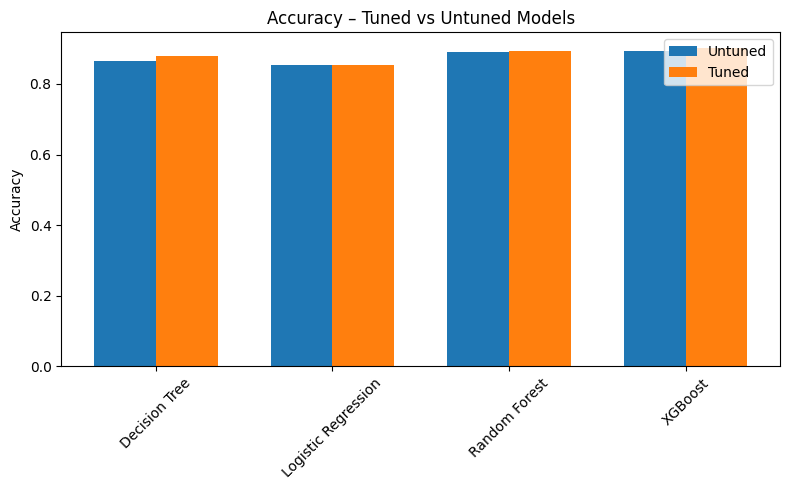

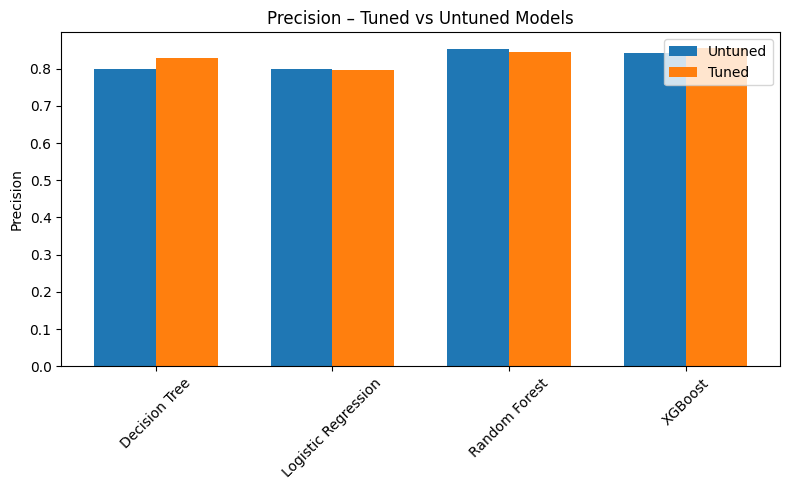

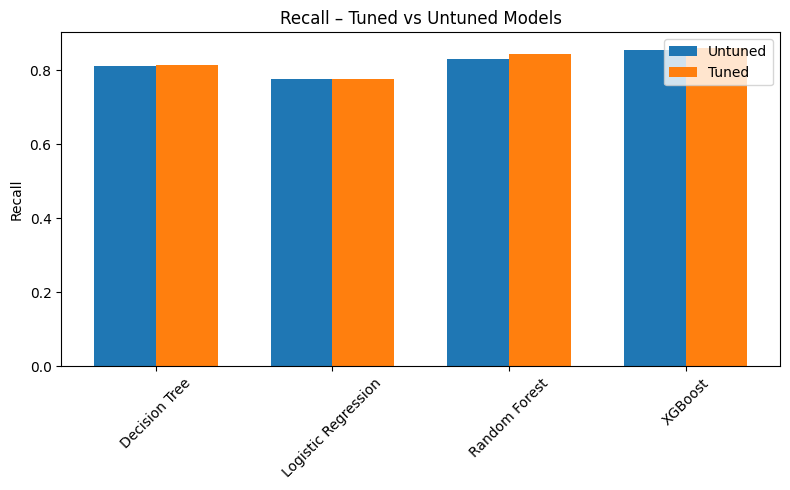

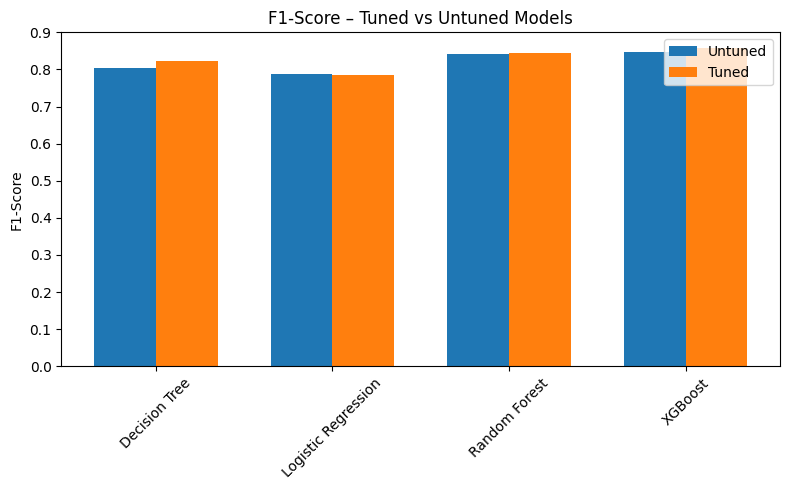

In [4]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

for metric in metrics:
    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, comparison_df[metric].values, width, label="Untuned")
    plt.bar(x + width/2, comparison_tuned_df[metric].values, width, label="Tuned")

    plt.xticks(x, models, rotation=45)
    plt.ylabel(metric)
    plt.title(f"{metric} – Tuned vs Untuned Models")
    plt.legend()
    plt.tight_layout()

    fname = f"{metric.lower().replace('-', '').replace(' ', '_')}_tuned_vs_untuned.png"
    plt.savefig(figures_dir / fname, dpi=300, bbox_inches="tight")
    plt.show()